# FastFHIR benchmark — figures

This notebook is a **thin wrapper around [`scripts/plot_benchmarks.py`](../scripts/plot_benchmarks.py)**.
All plotting logic lives in the script so the figures are identical whether they come from here, from CI, or from a
shell — a notebook that reimplements the charts is a second source of truth, and the old version of this notebook
was exactly that (four near-identical 8 KB cells of matplotlib, Postgres-only, and no size columns).

## Read this before citing anything from below

Every figure is stamped with its provenance, and with **PROVISIONAL — NOT AN ARTIFACT** unless the run passed the
gate in [`bench/provenance.hpp`](../bench/provenance.hpp). A run is provisional if it was not built `-c opt`, if the
profile could not be established unambiguously, if the seed was random, or if either tree was dirty.

The figures also carry the caveats that make specific comparisons unfair today — Test 1 is not at parity (PA-1),
`value[x]` is excluded from every arm (D2), Test 3 charges the FastFHIR arm a `print_json` penalty (PA-7). Those are
on the charts on purpose: a chart is the easiest thing here to screenshot into a slide.

See [`TASKS.md`](../TASKS.md) for what each ID means.

## 1 — Produce a run

Run the harness from a shell (not from here — it takes minutes and streams progress to stderr):

```bash
bazel build -c opt //bench:bench_harness
mkdir -p results/dev
./bazel-bin/bench/bench_harness \
  --runs 5 --bundle-max-mb 64 \
  --results-dir results/dev \
  --profile "us-core,billing,medication-admin,supply" \
  > results/dev/metrics.csv 2> results/dev/run.log
```

`--profile` is required for an artifact on any machine with more than one CMake build tree — the caches disagree and
the harness refuses to guess. Exit code 2 means a cross-arm parity mismatch (currently expected); exit 3 means the
provenance gate refused to write.

In [25]:
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Point at whichever run you want to plot. Each holds metrics.csv + provenance.json.
#   results/ra  — includes Test 2 random access (D4). Use this one.
#   results/xl  — large sweep, up to 316 MiB of FastFHIR wire, pre-D4 stage set.
# NOTE (PA-13): --bundle-targets-mb counts INGESTED SOURCE bytes, not bundle
# size. It overstates the bundle by ~20-30x, so read the wire columns, never
# the target.
RUN_DIR = REPO / 'results' / 'ra'
FIG_DIR = REPO / 'results' / 'figures-ra'

assert (RUN_DIR / 'metrics.csv').exists(), f'no metrics.csv in {RUN_DIR} — see the cell above'
print('run     :', RUN_DIR)
print('figures :', FIG_DIR)

run     : /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/ra
figures : /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra


## 2 — Render the figures

One call into the script. Add `--format both` for SVG alongside the PNGs, or `--db "host=... dbname=..."` instead of
`--csv` to read the latest run straight from PostgreSQL.

In [26]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, str(REPO / 'scripts' / 'plot_benchmarks.py'),
     '--csv', str(RUN_DIR / 'metrics.csv'),
     '--results-dir', str(RUN_DIR),
     '--out', str(FIG_DIR)],
    capture_output=True, text=True, cwd=REPO)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr, file=sys.stderr)
    raise SystemExit(f'plot_benchmarks.py exited {result.returncode}')

228 rows · 4 arms · [np.int64(16), np.int64(64), np.int64(256), np.int64(1024)] MB targets
provenance: /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/ra/provenance.json — PROVISIONAL
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig0_provenance.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig1_duration_by_stage.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig2_wire_size.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig3_random_access.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig8_recovery.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig7_compact_speed.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig4_enrich_delta.png
  wrote /Users/ryanlandvater/GitHub/FastFHIR-benchmark/results/figures-ra/fig5_distribution.png
  wrote /Users/ryanlandvater/GitHub/FastFHI

## 3 — Provenance

What built these numbers, and whether they are citable. If this says PROVISIONAL, nothing below may be quoted
outside this repo.

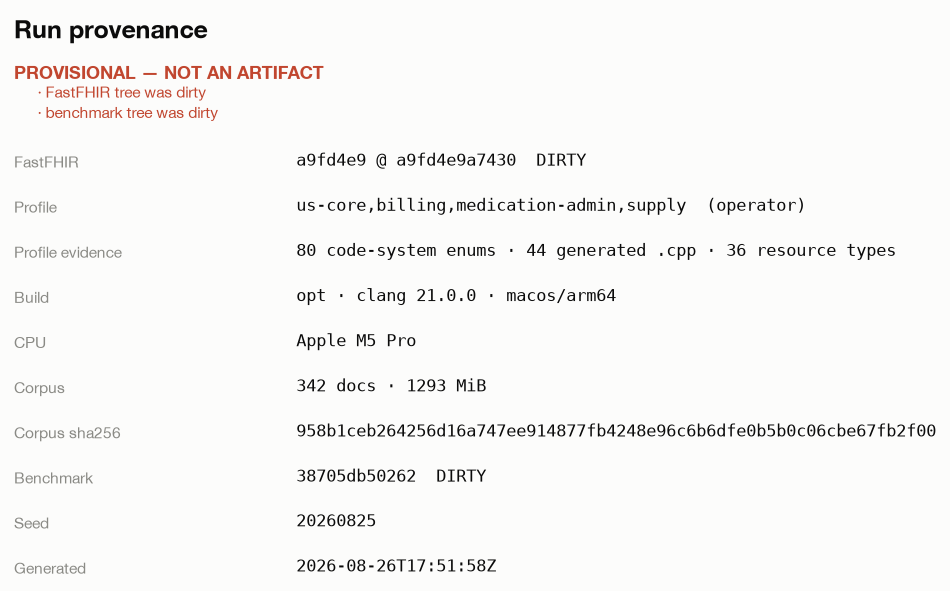

In [27]:
from IPython.display import Image, display, Markdown

display(Image(filename=str(FIG_DIR / 'fig0_provenance.png')))

## 4 — Duration by stage

Small multiples, log–log, one panel per stage.

**The x-axis is measured wire bytes, not `--bundle-max-mb`.** The fixture stops accumulating as soon as one patient
exceeds the target and each Synthea patient is ~3 MB ingested, so every target below ~4 MB yields a bundle of exactly
one randomly chosen patient — the 1 MB target can easily produce a *larger* bundle than the 2 MB one. Plotting
against the requested size below ~4 MB plots against noise.

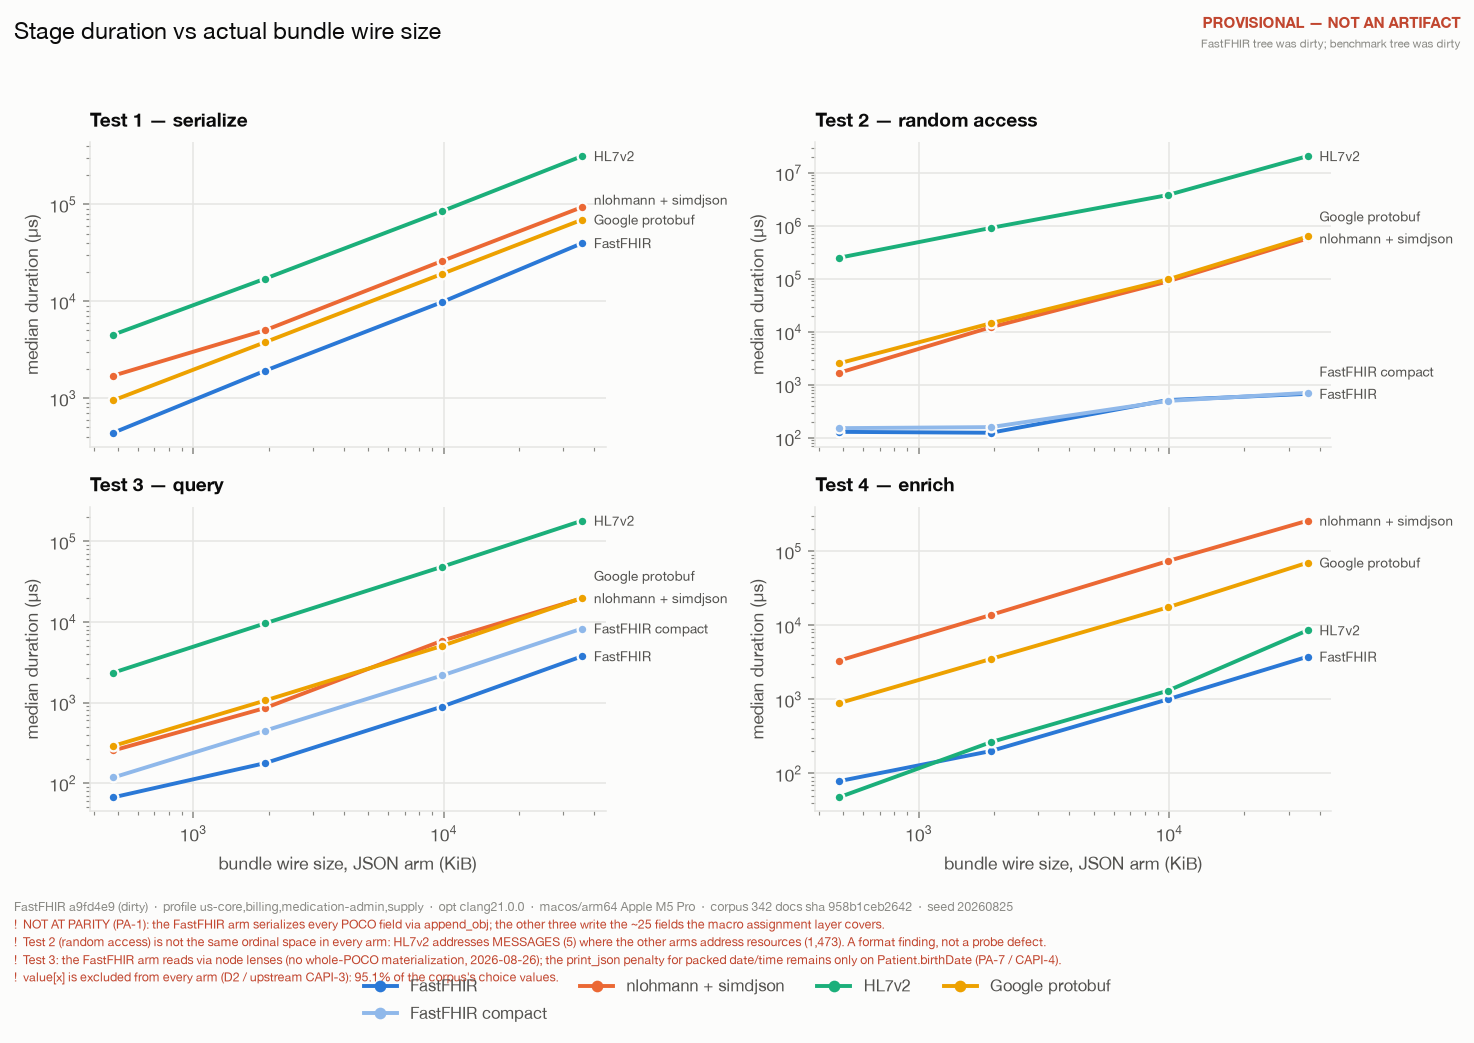

In [28]:
display(Image(filename=str(FIG_DIR / 'fig1_duration_by_stage.png')))

### Why does the Test 2 panel no longer show JSON winning?

It is the question this chart used to raise, and the answer was that the old Test 2 measured a **full traversal in
layout order** — a contiguous tape's best case and an offset-indexed layout's worst — while no consumer reads a
bundle in write order. **That stage was retired (TASKS.md D4, 2026-08-26):** Test 2 is now random access — N entry
reads, each navigating from the root — which is what § Why FastFHIR? actually claims (WF-1.1). The old analysis
(`entries()` allocations, the reflective `strlen`, simdjson's tape) is preserved in TASKS.md PA-11 for the record.

## 5 — Wire size

Only possible since IN-0 added the byte columns; before that nothing in this repo measured bytes.

The FastFHIR arm currently emits ~2.2x the JSON arm's bytes for the same content, because it serializes every POCO
field via `append_obj` while the others write the ~25 fields the macro assignment layer covers. That is **PA-1**, not
a format result — no size comparison is publishable until it closes.

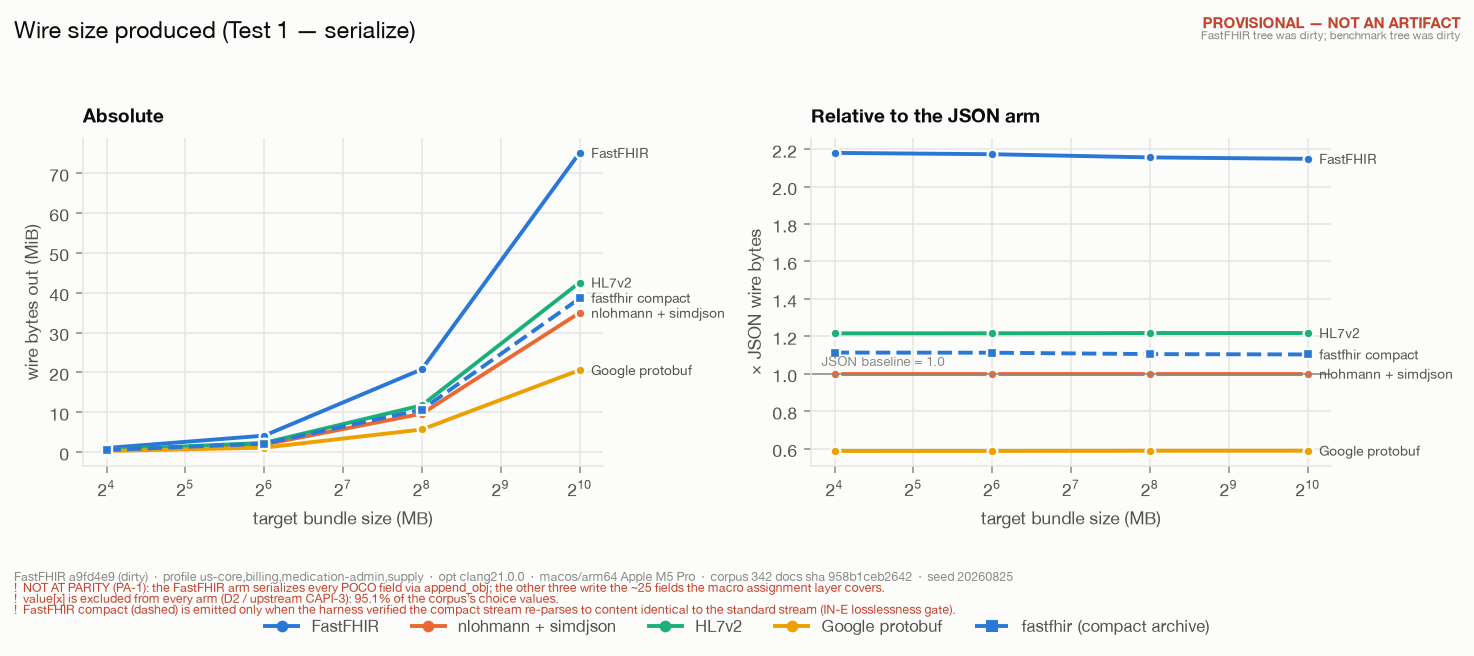

In [29]:
display(Image(filename=str(FIG_DIR / 'fig2_wire_size.png')))

## 6 — Random access (Test 2, D4)

**This is the measurement the repo was missing, and it is the one § Why FastFHIR? is actually about.** Test 2 picks
N random `Bundle.entry` ordinals, **navigates to each from the root**, and reads the resource's `id`. Every lookup
pays its own path cost — FastFHIR's is offset arithmetic (O(1)), the others scan (O(i)).

| bundle | FastFHIR | simdjson | protobuf | HL7v2 | FastFHIR vs simdjson |
|---|---:|---:|---:|---:|---:|
| ~0.5 MiB | 49.5 ns | 877 ns | 1,271 ns | 126,300 ns | **18×** |
| ~2 MiB | 62.1 ns | 6,125 ns | 7,360 ns | 450,647 ns | **99×** |
| ~10 MiB | 227.5 ns | 43,387 ns | 50,178 ns | 1,914,388 ns | **191×** |
| ~36 MiB | 344.9 ns | 295,397 ns | 322,183 ns | 10,519,591 ns | **856×** |

FastFHIR's cost is near-flat (49.5 → 344.9 ns as the bundle grows ~70×); the three scan formats climb linearly.
That is WF-1.1 — O(1) random access against O(N) scanning — measured. (The former receiver-side figure — wire
bytes ÷ materialize duration — died with the walk it measured; Instrument A is its intended replacement.)

Three things keep this honest:

- **Every arm reads the same fields.** The harness compares total bytes read across arms and fails the run if they
  disagree. That gate has already caught three real bugs (TASKS.md IN-B2).
- **HL7v2 is not doing the same operation.** A v2 batch has no resource-level index; its addressable unit is the
  message — 5 messages for those 1,473 resources. A finding about the format, not a probe defect.
- **The counterpoint is not yet measured.** A consumer wanting many random reads would build an index once and
  amortize it. The crossover is estimated near 50k reads and is **not to be quoted** until IN-B3 measures it.

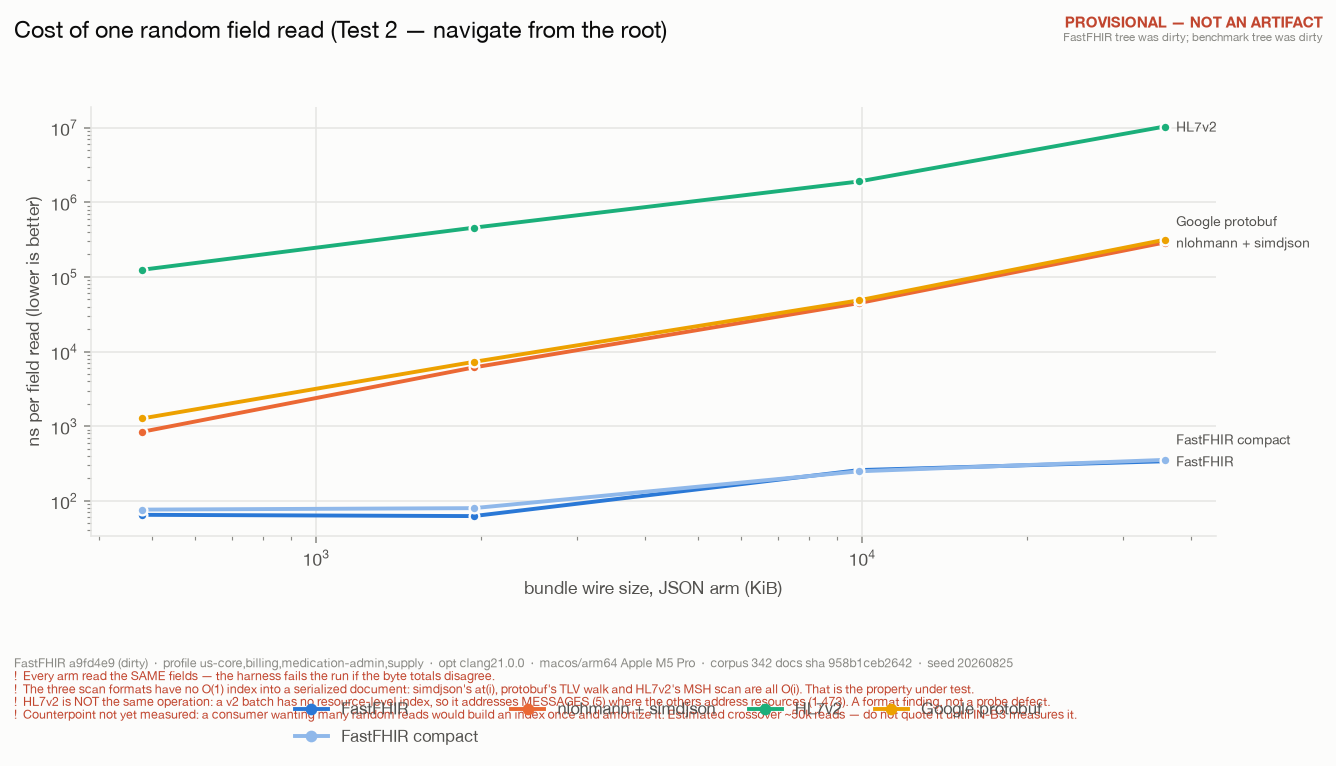

In [30]:
fig3 = FIG_DIR / 'fig3_random_access.png'
if fig3.exists():
    display(Image(filename=str(fig3)))
else:
    display(Markdown("**No Test 2 (random access) figure — this run predates D4.** "
                     "Re-run the harness (cell 1) with the current stage set."))

### Compact archive — about the same speed?

FastFHIR only. Compact rows exist only when the losslessness gate passed (IN-E).
Tests 2/3 read the compact stream with the same lens API — the ratio shows
whether the dense compact root costs anything at scale. **Test 4 (enrich) has NO
compact row**: the API refuses to open a Builder on a compact archive — compact
is write-once (CAPI-10).

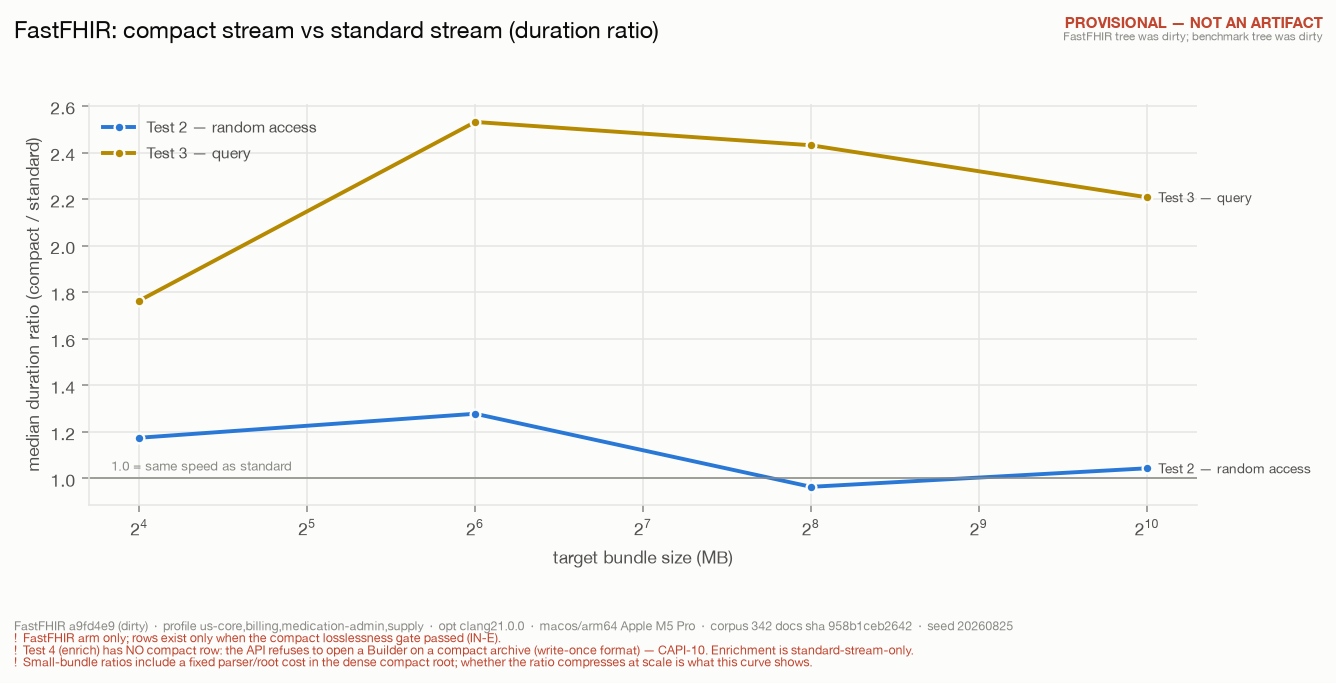

In [31]:
display(Image(filename=str(FIG_DIR / 'fig7_compact_speed.png')))

### Recoverability under corruption (Instrument G, test 5)

Four formats compared: random STRUCTURAL bits flipped (syntax regions — FFHR
header+block headers, JSON braces/quotes/commas, protobuf TLV record headers,
HL7v2 segment terminators+names) vs % recoverable. Corruption and recovery run
as INDEPENDENT processes (scripts/recovery_sweep.py) — the recoverer sees only
the corrupted bytes. FastFHIR and HL7v2 hold up (block/segment resync);
protobuf's length-prefixed TLV collapses. Units: entries for FFHR/JSON/protobuf,
segments for HL7v2. Data: `results/recovery_curve.csv` from
`scripts/recovery_sweep.py` (artifacts via `--dump-artifacts`).

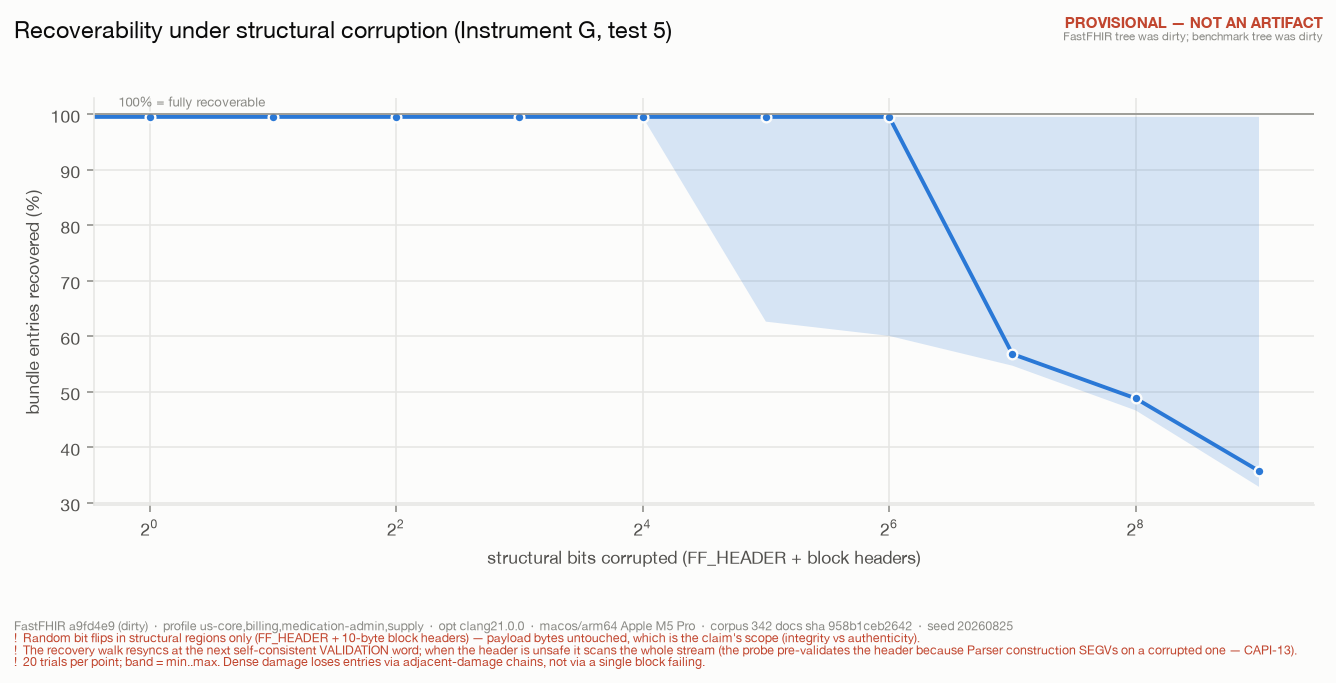

In [32]:
display(Image(filename=str(FIG_DIR / 'fig8_recovery.png')))

## 7 — Enrichment cost

Bytes added by appending a single Observation. The FastFHIR arm adds ~58 KB where protobuf adds 198 B, because it
appends a whole new root `Bundle` block rather than just the observation — the opposite of the "append without
touching any other byte" claim it is meant to demonstrate (**PA-10**). The arms are also not doing the same thing:
`FastFHIR::Memory` is a `shared_ptr` handle, so that arm appends in place while the others build a separate buffer
(**PA-9**).

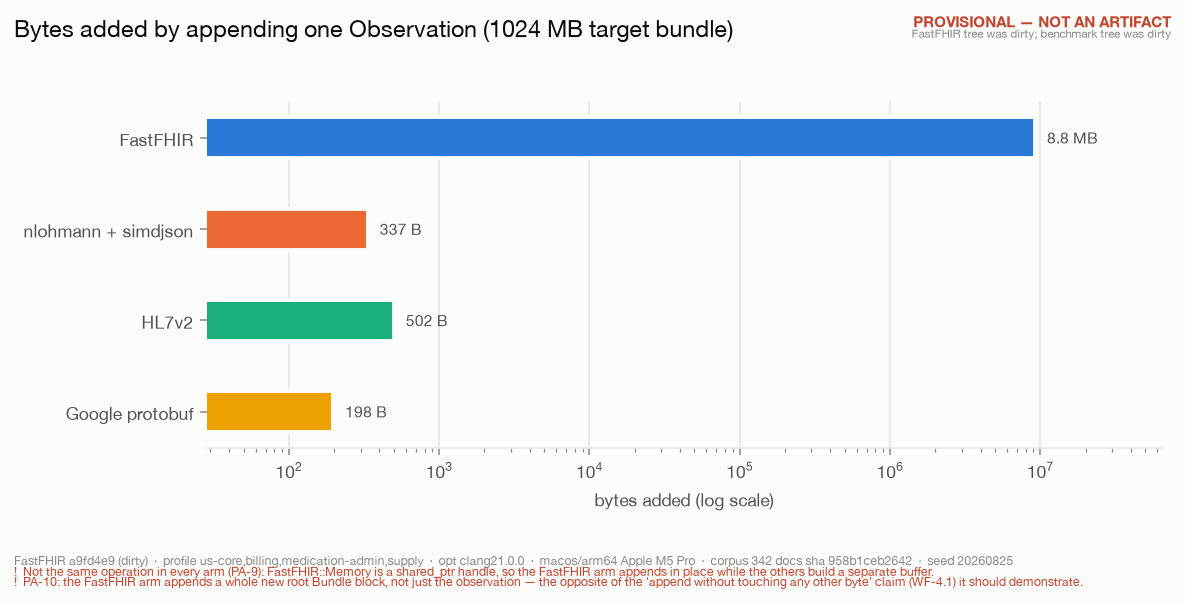

In [33]:
display(Image(filename=str(FIG_DIR / 'fig4_enrich_delta.png')))

## 8 — Distribution across runs

Violins, grouped by bundle size — restored from the pre-IN-0 notebook, which had these and was right to. A median
hides the thing a benchmark most needs to show: whether the spread is tight enough for the gap between two arms to
mean anything.

With `--runs 3` the kernel density is fitted to very few points, so **read the spread, not the shape**. Use
`--runs 10` or more before quoting anything from this panel.

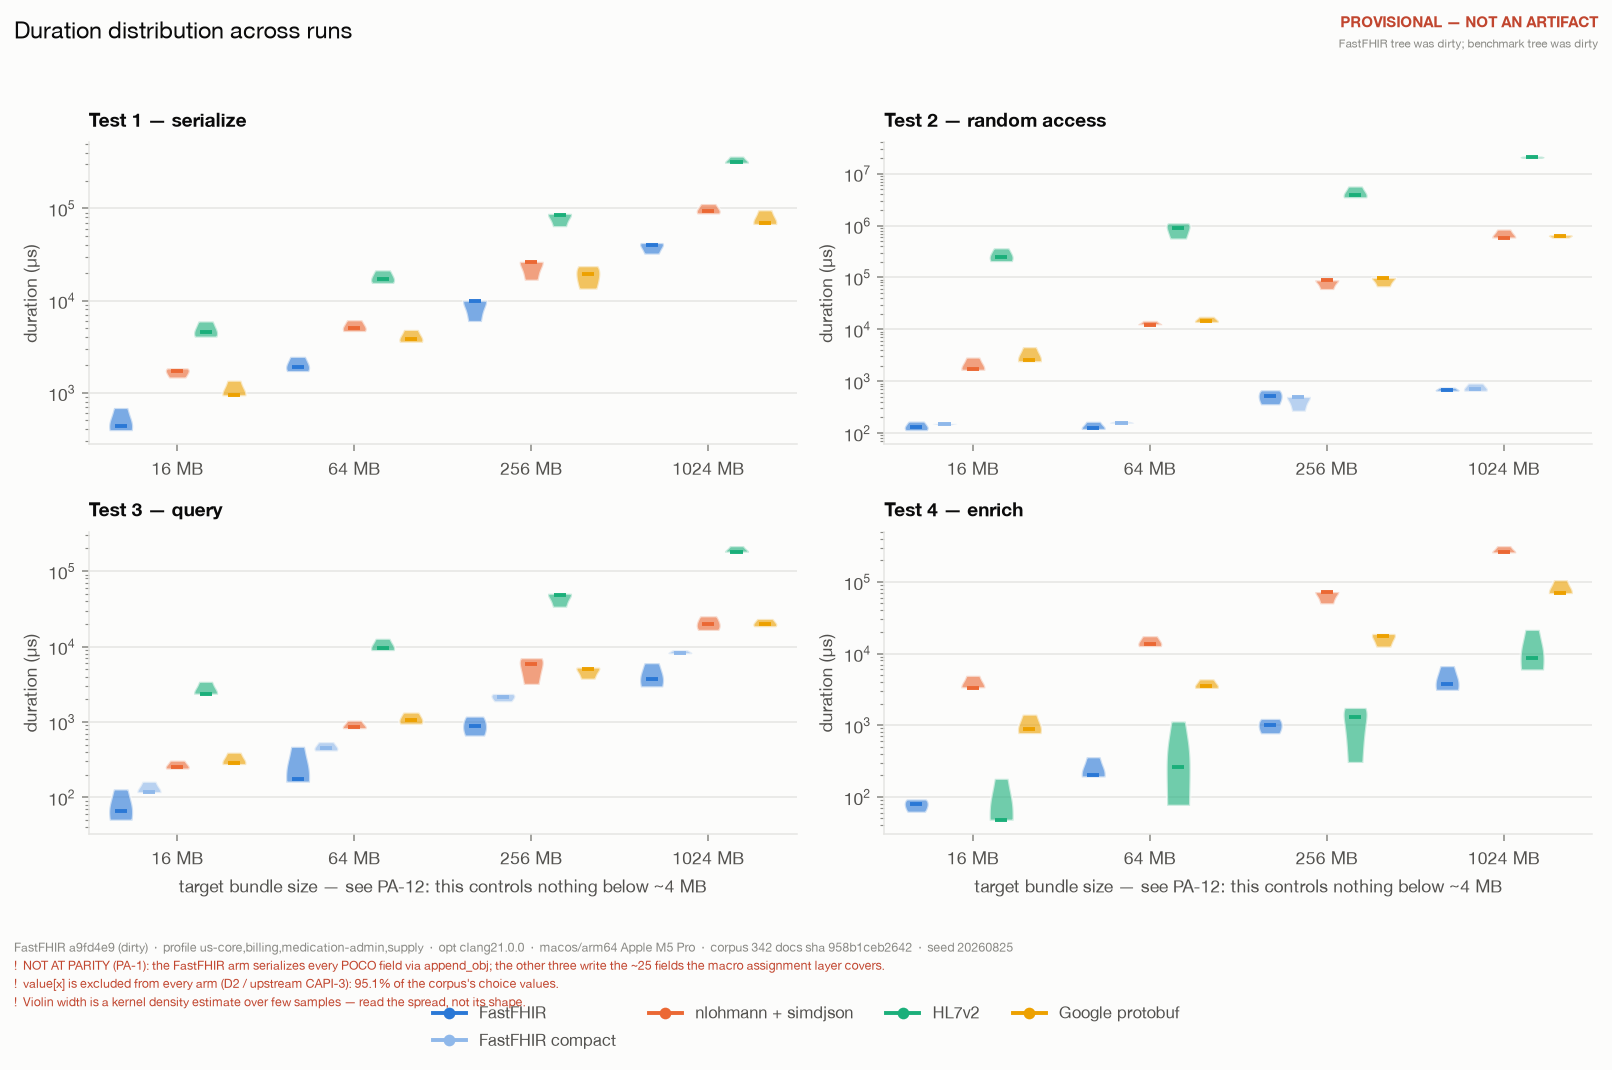

In [34]:
display(Image(filename=str(FIG_DIR / 'fig5_distribution.png')))

## 9 — Speedup vs each alternative

Ratios of median durations, anchored at parity. FastFHIR wins most of the arm×stage comparisons, several by a wide
margin — **4.91× vs simdjson on serialize while writing ~2.2× more bytes**, and **53× on enrich**. Sub-parity
results are drawn and labelled like any other: a speedup chart that only shows wins is advertising.

The former inversion — Test 2 vs simdjson at 0.37× — belonged to the materialize walk and died with it (D4): a full
traversal was the one workload where zero-copy has no advantage, because it visits nodes the query never would. With
Test 2 now random access, the stage is FastFHIR's strongest (up to ~856× at 36 MiB, section 6) instead of its only
loss.

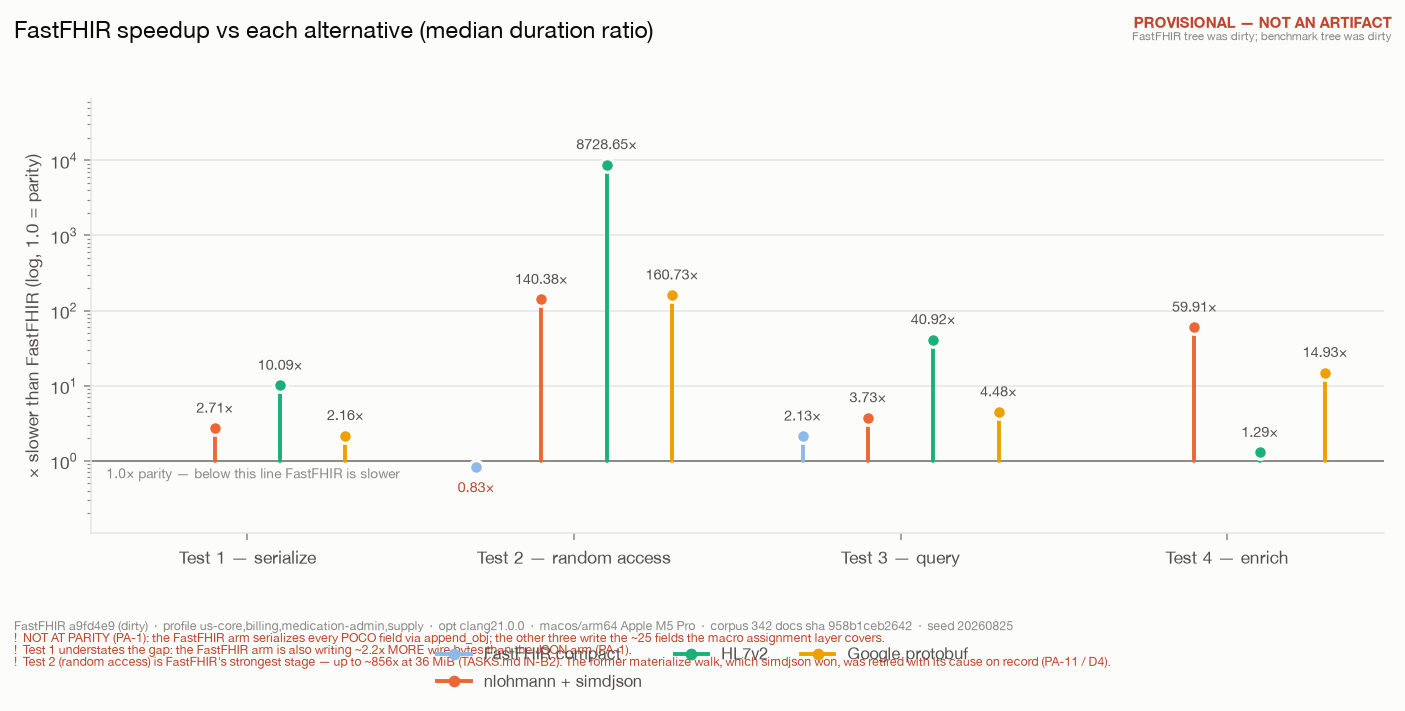

In [35]:
display(Image(filename=str(FIG_DIR / 'fig6_speedup.png')))

## 10 — Table view

In [36]:
display(Markdown((FIG_DIR / 'summary.md').read_text()))

# Benchmark summary

**PROVISIONAL — NOT AN ARTIFACT**

- FastFHIR tree was dirty
- benchmark tree was dirty

`FastFHIR a9fd4e9 (dirty)  ·  profile us-core,billing,medication-admin,supply  ·  opt clang21.0.0  ·  macos/arm64 Apple M5 Pro  ·  corpus 342 docs sha 958b1ceb2642  ·  seed 20260825`

## Caveats carried on every figure

- NOT AT PARITY (PA-1): the FastFHIR arm serializes every POCO field via append_obj; the other three write the ~25 fields the macro assignment layer covers.
- value[x] is excluded from every arm (D2 / upstream CAPI-3): 95.1% of the corpus's choice values.
- Test 2 (random access) is not the same ordinal space in every arm: HL7v2 addresses MESSAGES (5) where the other arms address resources (1,473). A format finding, not a probe defect.
- Test 3: the FastFHIR arm reads via node lenses (no whole-POCO materialization, 2026-08-26); the print_json penalty for packed date/time remains only on Patient.birthDate (PA-7 / CAPI-4).
- Not the same operation in every arm (PA-9): FastFHIR::Memory is a shared_ptr handle, so the FastFHIR arm appends in place while the others build a separate buffer.

## Medians by stage and arm

### Test 1 — serialize

| Arm | runs | median µs | p90 µs | ops | ns/op | median bytes in | median bytes out |
|---|---:|---:|---:|---:|---:|---:|---:|
| FastFHIR | 12 | 4,200.54 | 39,033.10 | 0 | — | 0 | 10,517,321 |
| nlohmann + simdjson | 12 | 11,393.33 | 93,204.56 | 0 | — | 0 | 4,862,431 |
| HL7v2 | 12 | 42,377.65 | 314,886.55 | 0 | — | 0 | 5,915,590 |
| Google protobuf | 12 | 9,081.21 | 69,305.16 | 0 | — | 0 | 2,858,526 |

### Test 2 — random access

| Arm | runs | median µs | p90 µs | ops | ns/op | median bytes in | median bytes out |
|---|---:|---:|---:|---:|---:|---:|---:|
| FastFHIR | 12 | 260.29 | 683.77 | 2,000 | 130.15 | 0 | 72,000 |
| nlohmann + simdjson | 12 | 36,539.37 | 578,018.53 | 2,000 | 18,269.69 | 0 | 72,000 |
| HL7v2 | 12 | 2,271,993.67 | 20,599,954.02 | 2,000 | 1,135,996.83 | 0 | 72,000 |
| Google protobuf | 12 | 41,835.98 | 623,963.13 | 2,000 | 20,917.99 | 0 | 72,000 |

### Test 3 — query

| Arm | runs | median µs | p90 µs | ops | ns/op | median bytes in | median bytes out |
|---|---:|---:|---:|---:|---:|---:|---:|
| FastFHIR | 12 | 563.62 | 3,678.66 | 0 | — | 0 | 0 |
| nlohmann + simdjson | 12 | 2,102.88 | 19,429.43 | 0 | — | 0 | 0 |
| HL7v2 | 12 | 23,064.02 | 180,995.70 | 0 | — | 0 | 0 |
| Google protobuf | 12 | 2,522.62 | 19,767.00 | 0 | — | 0 | 0 |

### Test 4 — enrich

| Arm | runs | median µs | p90 µs | ops | ns/op | median bytes in | median bytes out |
|---|---:|---:|---:|---:|---:|---:|---:|
| FastFHIR | 12 | 560.46 | 3,700.88 | 0 | — | 10,517,321 | 11,744,047 |
| nlohmann + simdjson | 12 | 33,575.67 | 258,209.35 | 0 | — | 4,862,431 | 4,862,768 |
| HL7v2 | 12 | 723.06 | 8,304.88 | 0 | — | 5,915,590 | 5,916,092 |
| Google protobuf | 12 | 8,367.42 | 69,984.70 | 0 | — | 2,858,526 | 2,858,724 |


In [37]:
import pandas as pd
pd.read_csv(FIG_DIR / 'summary.csv')

,test,arm,runs,median_us,p90_us,median_ops,median_bytes_in,median_bytes_out
0,test_1_compact,fastfhir,12,20889.06,262946.17,0.0,0.0,5389473.5
1,test_1_serialize,fastfhir,12,4200.54,39033.10,0.0,0.0,10517321.5
2,test_1_serialize,google_fhir,12,9081.21,69305.16,0.0,0.0,2858526.0
3,test_1_serialize,hl7v2,12,42377.65,314886.55,0.0,0.0,5915590.5
4,test_1_serialize,json_fhir,12,11393.33,93204.56,0.0,0.0,4862431.0
5,test_2_compact,fastfhir,12,215.67,699.32,2000.0,0.0,72000.0
6,test_2_random_access,fastfhir,12,260.29,683.77,2000.0,0.0,72000.0
7,test_2_random_access,google_fhir,12,41835.98,623963.13,2000.0,0.0,72000.0
8,test_2_random_access,hl7v2,12,2271993.67,20599954.02,2000.0,0.0,72000.0
9,test_2_random_access,json_fhir,12,36539.37,578018.53,2000.0,0.0,72000.0
